In [ ]:
!unzip Unet30.zip -d Unet-Dataset

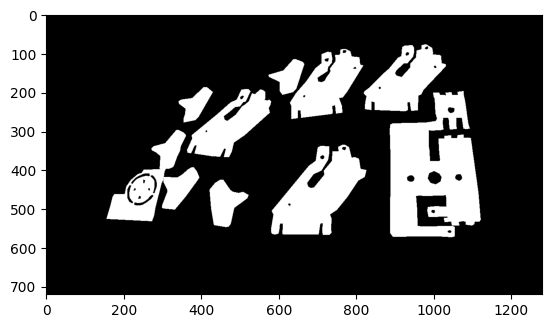

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt
img=cv.imread("/content/Unet-Dataset/Unet-Sheet/Masks/img11_png.rf.rryu5k3u0dqUVzrduR0x.png",0)
plt.imshow(img,cmap="gray")
plt.show()

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 1. Model Architecture
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class UNet1280x720(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet1280x720, self).__init__()
        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(512, 1024)
        self.up1 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.up_conv1 = DoubleConv(1024, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.up_conv2 = DoubleConv(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.up_conv3 = DoubleConv(256, 128)
        self.up4 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.up_conv4 = DoubleConv(128, 64)
        self.out_conv = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        d3 = self.down3(self.pool2(d2))
        d4 = self.down4(self.pool3(d3))
        bn = self.bottleneck(self.pool4(d4))
        u1 = self.up1(bn)
        u1 = self.up_conv1(torch.cat([u1, d4], dim=1))
        u2 = self.up2(u1)
        u2 = self.up_conv2(torch.cat([u2, d3], dim=1))
        u3 = self.up3(u2)
        u3 = self.up_conv3(torch.cat([u3, d2], dim=1))
        u4 = self.up4(u3)
        u4 = self.up_conv4(torch.cat([u4, d1], dim=1))
        return self.out_conv(u4)

# 2. Combined Loss
class DiceBCELoss(nn.Module):
    def forward(self, inputs, targets, smooth=1):
        inputs = torch.sigmoid(inputs).view(-1)
        targets = targets.view(-1)
        intersection = (inputs * targets).sum()
        dice = 1 - (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)
        BCE = F.binary_cross_entropy(inputs, targets, reduction='mean')
        return BCE + dice

# 3. Dataset
class UNetDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images_dir, self.masks_dir, self.transform = images_dir, masks_dir, transform
        self.images = [f for f in os.listdir(images_dir) if f.endswith(('.png', '.jpg'))]
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.images_dir, self.images[idx])).convert("RGB").resize((1280, 720))
        mask = Image.open(os.path.join(self.masks_dir, self.images[idx])).convert("L").resize((1280, 720))
        img = self.transform(img)
        mask = self.transform(mask)
        return img, (mask > 0).float()

# 4. Training Loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet1280x720().to(device)
loader = DataLoader(UNetDataset("/content/Unet-Dataset/Unet-Sheet/Images", "/content/Unet-Dataset/Unet-Sheet/Masks/", transforms.ToTensor()), batch_size=2, shuffle=True)
criterion, optimizer = DiceBCELoss(), optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(30):
    model.train()
    total_loss = 0
    for imgs, msks in loader:
        imgs, msks = imgs.to(device), msks.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), msks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

torch.save(model.state_dict(), "Unet1280x720.pth")

Epoch 1, Loss: 0.8786
Epoch 2, Loss: 0.5794
Epoch 3, Loss: 0.4672
Epoch 4, Loss: 0.4234
Epoch 5, Loss: 0.3919
Epoch 6, Loss: 0.3657
Epoch 7, Loss: 0.3494
Epoch 8, Loss: 0.3232
Epoch 9, Loss: 0.3359
Epoch 10, Loss: 0.3212
Epoch 11, Loss: 0.3055
Epoch 12, Loss: 0.3014
Epoch 13, Loss: 0.2874
Epoch 14, Loss: 0.3053
Epoch 15, Loss: 0.3246
Epoch 16, Loss: 0.3007
Epoch 17, Loss: 0.2579
Epoch 18, Loss: 0.2652
Epoch 19, Loss: 0.2541
Epoch 20, Loss: 0.2514
Epoch 21, Loss: 0.2339
Epoch 22, Loss: 0.2162
Epoch 23, Loss: 0.2228
Epoch 24, Loss: 0.2113
Epoch 25, Loss: 0.2069
Epoch 26, Loss: 0.2159
Epoch 27, Loss: 0.2055
Epoch 28, Loss: 0.1851
Epoch 29, Loss: 0.1859
Epoch 30, Loss: 0.1886


Successfully loaded weights from /content/Unet1280x720.pth


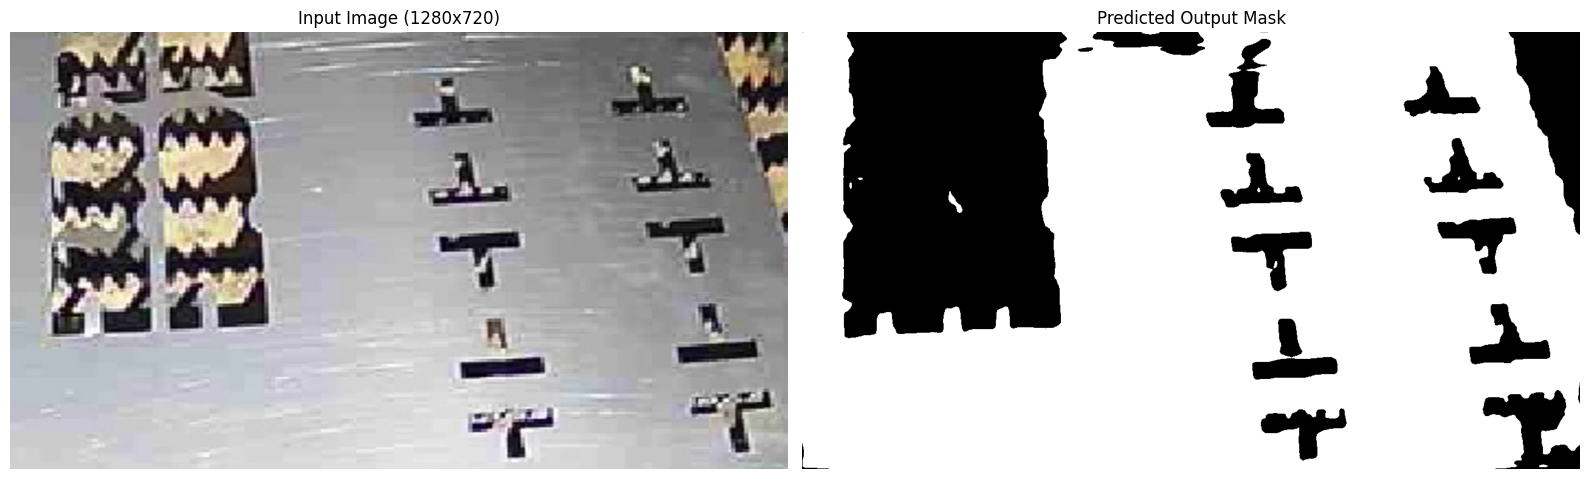

In [ ]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet1280x720(in_channels=3, out_channels=1).to(device)

weights_path = "/content/Unet1280x720.pth"
if os.path.exists(weights_path):
    model.load_state_dict(torch.load(weights_path, map_location=device))
    print(f"Successfully loaded weights from {weights_path}")
else:
    print("Warning: Weights file not found. Ensure the path is correct.")
model.eval()

test_image_path = "test-img-path"

if os.path.exists(test_image_path):
    # Load and resize
    img = Image.open(test_image_path).convert("RGB")
    img_resized = img.resize((1280, 720)) # Force 1280x720

    # Convert to tensor and add batch dimension: shape [1, 3, 720, 1280]
    transform = transforms.ToTensor()
    img_tensor = transform(img_resized).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.sigmoid(output)
        mask = (probs > 0.5).float()

    mask_np = mask.squeeze().cpu().numpy()

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(16, 8))

    ax[0].imshow(img_resized)
    ax[0].set_title(f"Input Image (1280x720)")
    ax[0].axis("off")

    ax[1].imshow(mask_np, cmap="gray")
    ax[1].set_title("Predicted Output Mask")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print(f"Error: Could not find the image at {test_image_path}. Please check the filename.")